# Dark Matter Spectral Distortions: PDE vs GF

Generates `pde_gf_dm_comparison.pdf` (Figure 4 in paper).

Three DM scenarios (decay, s-wave, p-wave annihilation) compared across PDE solver, CosmoTherm GF convolution, and spectroxide GF table.

In [7]:
import os
from pathlib import Path

# Ensure cargo is on PATH
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt

import sys, pathlib

from spectroxide import (
    apply_style, C, SINGLE_COL, DOUBLE_COL,
    run_sweep, solve, delta_n_to_delta_I, g_bb, KAPPA_C,
    hubble, n_hydrogen, rho_gamma, cosmic_time,
    DEFAULT_COSMO,
)
from spectroxide.greens import COSMOTHERM_GF_COSMO
from spectroxide.cosmotherm import (
    load_greens_database,
    convolve_cosmotherm_gf, strip_gbb,
    ct_heating_rate_swave, ct_heating_rate_pwave, ct_heating_rate_decay,
    cosmotherm_gf_distortion,
)
from spectroxide.plot_params import (
    LW, LW_THIN, LW_AXIS, ANNOT_SIZE, LEGEND_SIZE,
    RESID_BAND, RESID_BAND_ALPHA, RESID_MASK_FRAC,
    SAVE_DPI,
)

apply_style()

_K_B = 1.380_649e-23
_H_PL = 6.626_070_15e-34
_T_CMB = 2.726

colors = {"Decay": C["blue"], "s-wave": C["orange"], "p-wave": C["teal"]}

## DM scenario parameters

In [8]:
# Parameters chosen so drho/rho ~ 1e-5 for all three scenarios.
cosmo = DEFAULT_COSMO
n_H_0 = n_hydrogen(0, cosmo)
z_X = 5e4
gamma_x = 1.0 / cosmic_time(z_X + 10, cosmo)

# Rust f_ann is in the PAPER convention [eV/s], same as CosmoTherm.
# No division by n_H_0 needed.
f_X_CT = 7.757e5        # decay: f_X [eV]
f_ann_CT_sw = 3.758e-20  # s-wave [eV/s]
f_ann_CT_pw = 5.789e-26  # p-wave [eV/s]

# Same values for both Rust PDE and CosmoTherm GF convolutions
f_ann_sw = f_ann_CT_sw  # paper convention, NOT volumetric
f_ann_pw = f_ann_CT_pw  # paper convention, NOT volumetric

print(f'Gamma_X = {gamma_x:.3e}/s')
print(f'Decay:  f_X = {f_X_CT:.3e} eV')
print(f's-wave: f_ann = {f_ann_CT_sw:.3e} eV/s')
print(f'p-wave: f_ann = {f_ann_CT_pw:.3e} eV/s')

# Integration range
Z_START = 5e6
Z_END = 1001
N_Z_CONV = 5000


Gamma_X = 1.072e-10/s
Decay:  f_X = 7.757e+05 eV
s-wave: f_ann = 3.758e-20 eV/s
p-wave: f_ann = 5.789e-26 eV/s


## CosmoTherm GF convolution

In [9]:
z_h_ct, x_ct, g_th_ct = load_greens_database()
print(f'GF database: {len(z_h_ct)} redshifts x {len(x_ct)} frequencies')

ct_heating = {
    'Decay':  lambda z: ct_heating_rate_decay(z, f_X_CT, gamma_x),
    's-wave': lambda z: ct_heating_rate_swave(z, f_ann_CT_sw),
    'p-wave': lambda z: ct_heating_rate_pwave(z, f_ann_CT_pw),
}

gf_conv = {}
for name, dq_func in ct_heating.items():
    x_out, di_raw = convolve_cosmotherm_gf(
        z_h_ct, x_ct, g_th_ct, dq_func,
        z_min=Z_END, z_max=Z_START, n_z=N_Z_CONV,
    )
    # NC-strip CT result for symmetric comparison: DeltaI -> Delta_n -> strip -> DeltaI
    nu_hz = x_out * _K_B * _T_CMB / _H_PL
    nu_out = nu_hz / 1e9
    dn_ct_raw = di_raw * 1e-26 * (3e8)**2 / (2.0 * _H_PL * nu_hz**3)
    dn_ct_nc, _ = strip_gbb(x_out, dn_ct_raw)
    _, di = delta_n_to_delta_I(x_out, dn_ct_nc)
    gf_conv[name] = (x_out, nu_out, di)
    print(f'  {name}: peak |DI| = {np.max(np.abs(di)):.4e} Jy/sr')


GF database: 118 redshifts x 4190 frequencies
  Decay: peak |DI| = 4.6945e+03 Jy/sr
  s-wave: peak |DI| = 3.5455e+03 Jy/sr
  p-wave: peak |DI| = 1.4289e+03 Jy/sr


## PDE GF table (build or load cache)

In [11]:
from spectroxide.greens_table import load_or_build_greens_table

_HQ_CACHE = Path.home() / '.spectroxide' / 'greens_table_hq.npz'
heat_table = load_or_build_greens_table(
    cache_path=_HQ_CACHE,
    # rebuild=True,
    z_injections=np.logspace(np.log10(1e3), np.log10(5e6), 200),
    n_points=8000, n_x=4000, x_min=0.005, x_max=40.0, z_end=1001,
    timeout=3600,
    dy_max=0.005,
)
x_obs = np.linspace(0.1, 25, 1000)
print(f'PDE GF table: {len(heat_table.z_h)} redshifts, {len(heat_table.x)} freq pts')


PDE GF table: 200 redshifts, 4000 freq pts


## Convolve PDE GF table with DM heating rates

In [12]:
pde_gf_conv = {}
for name, dq_func in ct_heating.items():
    dn_tab = heat_table.distortion_from_heating(heat_table.x, dq_func, Z_END, Z_START, n_z=N_Z_CONV)
    # Library convolution returns raw Δn; strip on cache.x for symmetry with PDE/CT.
    dn_tab_nc, _ = strip_gbb(heat_table.x, dn_tab)
    nu_tab, di_tab = delta_n_to_delta_I(heat_table.x, dn_tab_nc)
    pde_gf_conv[name] = (heat_table.x, nu_tab, di_tab)
    print(f'  {name}: peak |DI| = {np.max(np.abs(di_tab)):.4e} Jy/sr')


  Decay: peak |DI| = 4.6894e+03 Jy/sr
  s-wave: peak |DI| = 3.5537e+03 Jy/sr
  p-wave: peak |DI| = 1.4241e+03 Jy/sr


## Direct PDE runs

In [ ]:
import concurrent.futures

dm_injections = {
    'Decay': {'type': 'decaying-particle', 'f_x': f_X_CT, 'gamma_x': gamma_x},
    's-wave': {'type': 'annihilating-dm', 'f_ann': f_ann_sw},
    'p-wave': {'type': 'annihilating-dm-pwave', 'f_ann': f_ann_pw},
}

def run_pde(name_inj):
    name, inj = name_inj
    print(f'Running PDE: {name}...', flush=True)
    sw = solve(
        injection=inj, delta_rho=1e-5,
        z_start=Z_START, z_end=Z_END, n_points=8000,
        number_conserving=True,
        timeout=3600,
        dy_max=0.005
    )
    print(f'  {name} done.', flush=True)
    return name, {"x": sw.x.tolist(), "delta_n": sw.delta_n.tolist(),
                  "pde_mu": sw.mu, "pde_y": sw.y,
                  "drho": sw.delta_rho_over_rho, "z_h": sw.z_h}

with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
    futures = [executor.submit(run_pde, item) for item in dm_injections.items()]
    pde_results = {}
    for f in concurrent.futures.as_completed(futures):
        name, result = f.result()
        pde_results[name] = result

for name in ['Decay', 's-wave', 'p-wave']:
    r = pde_results[name]
    drho = r.get('drho', r.get('delta_rho_over_rho', 0))
    print(f'  {name}: Drho/rho={drho:.3e}')


## Strip G_bb from PDE

In [14]:
pde_no_gbb = {}
for name, r in pde_results.items():
    x_pde = np.array(r['x'])
    dn_pde = np.array(r['delta_n'])
    dn_stripped, alpha = strip_gbb(x_pde, dn_pde)
    pde_no_gbb[name] = (x_pde, dn_stripped)
    print(f'{name:>7s}: DT/T = {alpha:+.3e}')


 s-wave: DT/T = +3.893e-07
 p-wave: DT/T = +1.647e-06
  Decay: DT/T = +1.212e-09


## Figure

Decay: RMS(PDE vs CT)=0.12%
s-wave: RMS(PDE vs CT)=0.89%
p-wave: RMS(PDE vs CT)=0.72%


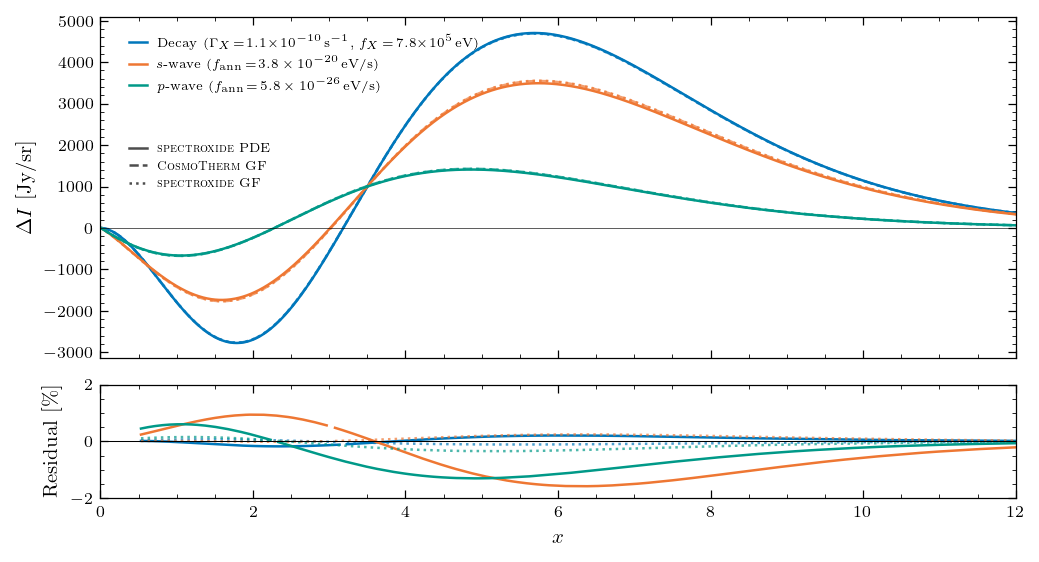

Saved to /home/bakerem/cosmoxide/notebooks/figures/pde_gf_dm_comparison.pdf


In [17]:
NU_TO_X = 1.0 / 56.786

labels = {
    'Decay': r'Decay ($\Gamma_X\!=\!1.1\!\times\! 10^{-10}\,$s$^{-1}$, $f_X\!=\!7.8\!\times\!10^5\,$eV)',
    's-wave': r'$s$-wave ($f_{\rm ann}\!=\!3.8\times10^{-20}\,$eV/s)',
    'p-wave': r'$p$-wave ($f_{\rm ann}\!=\!5.8\times10^{-26}\,$eV/s)',
}

fig, (ax, ax_b) = plt.subplots(2, 1, figsize=(DOUBLE_COL, 3.8),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for name in ['Decay', 's-wave', 'p-wave']:
    col = colors[name]

    # PDE
    x_pde, dn_pde = pde_no_gbb[name]
    nu_pde, di_pde = delta_n_to_delta_I(x_pde, dn_pde)

    # PDE GF table (entries already NC)
    _, nu_tab, di_tab = pde_gf_conv[name]

    # CosmoTherm GF (already no Gbb)
    x_ct_out, nu_ct, di_ct = gf_conv[name]

    # Plot raw DI
    ax.plot(nu_pde * NU_TO_X, di_pde, color=col, ls='-', lw=LW, label=labels[name])
    ax.plot(x_ct_out, di_ct, color=col, ls='--', lw=LW, alpha=0.7)
    ax.plot(nu_tab * NU_TO_X, di_tab, color=col, ls=':', lw=LW, alpha=0.7)

    # Residual
    peak_pde = np.max(np.abs(di_pde))
    nu_ct_ghz = x_ct_out * _K_B * _T_CMB / _H_PL / 1e9
    di_pde_at_ct = np.interp(nu_ct_ghz, nu_pde, di_pde)
    mask = (np.abs(di_ct) > RESID_MASK_FRAC * peak_pde) & (nu_ct_ghz > 30) & (nu_ct_ghz < 857)
    pct = np.full_like(di_ct, np.nan)
    pct[mask] = (di_pde_at_ct[mask] - di_ct[mask]) / peak_pde * 100
    ax_b.plot(x_ct_out, pct, color=col, ls='-', lw=LW)
    rms = np.sqrt(np.nanmean(pct[mask]**2))

    di_tab_at_ct = np.interp(nu_ct_ghz, nu_tab, di_tab)
    pct_tab = np.full_like(di_ct, np.nan)
    pct_tab[mask] = (di_tab_at_ct[mask] - di_ct[mask]) / peak_pde * 100
    ax_b.plot(x_ct_out, pct_tab, color=col, ls=':', lw=LW, alpha=0.7)

    print(f'{name}: RMS(PDE vs CT)={rms:.2f}%')

ax.axhline(0, color='k', lw=0.3)
ax.set_ylabel(r'$\Delta I$ [Jy/sr]')

# Place both legends in the upper-left region where curves dip below zero
# (avoids overlap with Decay peak on the right and p-wave curve near x=9).
leg1 = ax.legend(fontsize=LEGEND_SIZE - 1,
                 loc='upper left', bbox_to_anchor=(0.02, 0.98),
                 ncol=1, framealpha=0.9)
from matplotlib.lines import Line2D
method_handles = [
    Line2D([], [], color='0.3', ls='-',  lw=LW, label=r'\textsc{spectroxide} PDE'),
    Line2D([], [], color='0.3', ls='--', lw=LW, label=r'\textsc{CosmoTherm} GF'),
    Line2D([], [], color='0.3', ls=':',  lw=LW, label=r'\textsc{spectroxide} GF'),
]
leg2 = ax.legend(handles=method_handles, fontsize=LEGEND_SIZE - 1,
                 loc='upper left', bbox_to_anchor=(0.02, 0.66),
                 framealpha=0.9,)
ax.add_artist(leg1)
ax.set_xlim(0, 12)

ax_b.axhline(0, color='k', lw=0.5)
ax_b.set_ylim(-2, 2)
ax_b.set_xlabel(r'$x$')
ax_b.set_ylabel(r'Residual [\%]')

fig.tight_layout()
plt.savefig(FIG_DIR / 'pde_gf_dm_comparison.pdf', dpi=SAVE_DPI)
plt.show()
print(f'Saved to {FIG_DIR / "pde_gf_dm_comparison.pdf"}')